# 19 · Advanced Topics — Anomaly Detection, Imbalanced Data & Ensemble Methods

**Difficulty:** Advanced | **Time:** ~3 hours

## Table of Contents
1. Handling Imbalanced Datasets
2. Anomaly/Outlier Detection
3. Advanced Ensemble Methods (Stacking, Voting)
4. SHAP — Model Explainability
5. AutoML Concepts
6. ML Project Checklist

## 1. Imbalanced Datasets — The Real-World Problem

Most real classification tasks are imbalanced:
- Fraud detection: 0.1% fraud
- Medical diagnosis: 2% positive
- Churn: 5-10% churn

A model that always predicts the majority class gets 99% accuracy but is **useless**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix,
                              f1_score, precision_recall_curve, average_precision_score)
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

# Imbalanced dataset: fraud detection
np.random.seed(42)
X_imb, y_imb = make_classification(n_samples=5000, n_features=20, n_informative=10,
                                     n_redundant=5, weights=[0.95, 0.05],
                                     random_state=42)

print(f'Class distribution: {np.bincount(y_imb)}')
print(f'Fraud rate: {y_imb.mean():.1%}')

Class distribution: [4727  273]
Fraud rate: 5.5%


In [2]:
from sklearn.utils.class_weight import compute_class_weight

X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.2,
                                            random_state=42, stratify=y_imb)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)

# Strategy 1: No handling (baseline — bad!)
base = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)

# Strategy 2: class_weight='balanced'
cw = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_tr_s, y_tr)

# Strategy 3: Threshold tuning
base_probs = base.predict_proba(X_te_s)[:,1]

print(f'{'Strategy':<30} {'AUC':>8} {'F1 Fraud':>10} {'Recall':>10}')
print('-' * 60)
for name, model in [('No handling', base), ('class_weight=balanced', cw)]:
    yp = model.predict(X_te_s)
    yprob = model.predict_proba(X_te_s)[:,1]
    auc = roc_auc_score(y_te, yprob)
    f1  = f1_score(y_te, yp)
    rec = (yp[y_te==1]==1).mean()
    print(f'{name:<30} {auc:>8.3f} {f1:>10.3f} {rec:>10.1%}')

# Threshold tuning for base model
for t in [0.1, 0.2, 0.3, 0.5]:
    yp_t = (base_probs >= t).astype(int)
    f1_t = f1_score(y_te, yp_t)
    rec_t = (yp_t[y_te==1]==1).mean()
    print(f'Threshold={t}:{' ':<20} {roc_auc_score(y_te,base_probs):>8.3f} {f1_t:>10.3f} {rec_t:>10.1%}')

Strategy                            AUC   F1 Fraud     Recall
------------------------------------------------------------
No handling                       0.894      0.474      32.7%
class_weight=balanced             0.892      0.390      85.5%
Threshold=0.1:                        0.894      0.483      76.4%
Threshold=0.2:                        0.894      0.557      58.2%
Threshold=0.3:                        0.894      0.611      52.7%
Threshold=0.5:                        0.894      0.474      32.7%


In [3]:
try:
    from imblearn.over_sampling  import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBL = True
    print('imbalanced-learn available!')
except ImportError:
    HAS_IMBL = False
    print('imbalanced-learn not installed. Install: pip install imbalanced-learn')
    print('Showing what SMOTE does conceptually:')

if HAS_IMBL:
    smote = SMOTE(random_state=42)
    X_sm, y_sm = smote.fit_resample(X_tr_s, y_tr)
    lr_sm = LogisticRegression(max_iter=1000).fit(X_sm, y_sm)
    yp_sm = lr_sm.predict(X_te_s)
    yprob_sm = lr_sm.predict_proba(X_te_s)[:,1]
    print(f'SMOTE: AUC={roc_auc_score(y_te,yprob_sm):.3f}, F1={f1_score(y_te,yp_sm):.3f}')
else:
    # Visualize SMOTE conceptually
    np.random.seed(42)
    minority = np.random.randn(10, 2) + [2, 2]
    majority = np.random.randn(100, 2)
    synthetic = minority + np.random.randn(20, 2) * 0.3  # synthetic minority samples
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(majority[:,0], majority[:,1], alpha=0.4, s=20, color='steelblue', label='Majority')
    axes[0].scatter(minority[:,0], minority[:,1], s=80, color='red', label='Minority (real)')
    axes[0].set_title('Before SMOTE — Imbalanced'); axes[0].legend()
    
    axes[1].scatter(majority[:,0], majority[:,1], alpha=0.4, s=20, color='steelblue', label='Majority')
    axes[1].scatter(minority[:,0], minority[:,1], s=80, color='red', label='Minority (real)')
    axes[1].scatter(synthetic[:,0], synthetic[:,1], s=80, color='orange', marker='^', label='SMOTE Synthetic')
    axes[1].set_title('After SMOTE — Balanced'); axes[1].legend()
    
    plt.tight_layout(); plt.savefig('/tmp/smote.png', dpi=100); plt.show()

imbalanced-learn available!
SMOTE: AUC=0.894, F1=0.402


## 2. Anomaly Detection

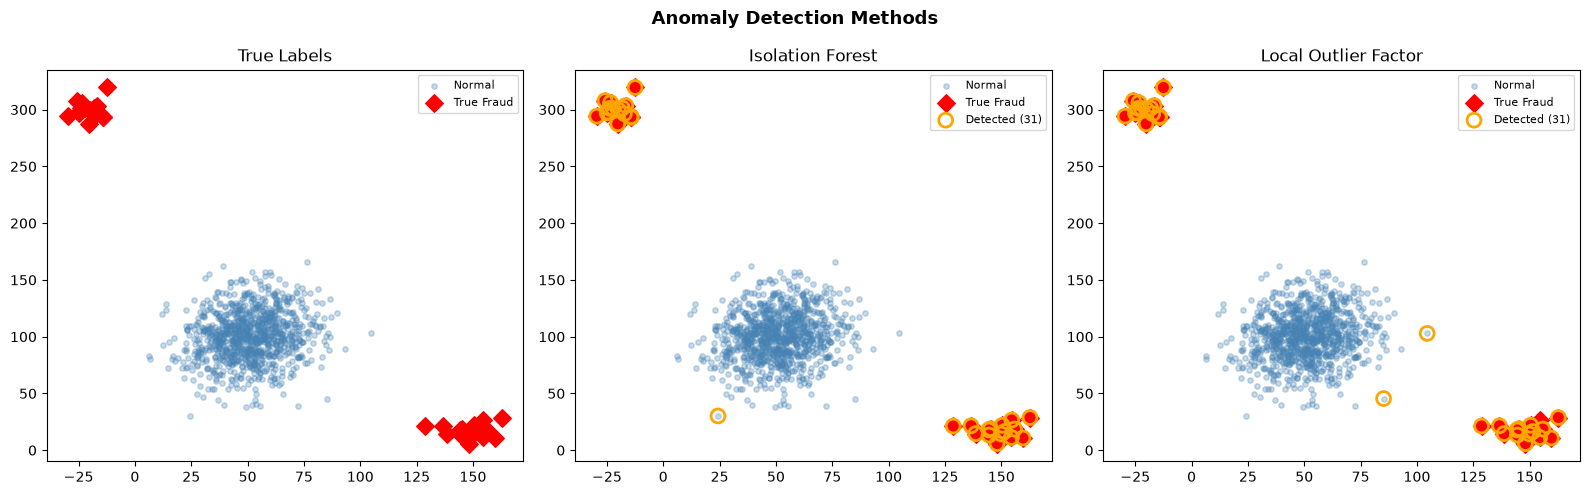

In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Credit card transaction anomaly detection
np.random.seed(42)
n_normal = 1000
n_fraud  = 30

# Normal transactions: cluster around mean
normal = np.random.multivariate_normal([50, 100], [[200, 50],[50, 500]], n_normal)
# Fraud: outliers in unusual places
fraud  = np.r_[
    np.random.multivariate_normal([150, 20], [[50, 0],[0, 50]], n_fraud//2),
    np.random.multivariate_normal([-20, 300], [[50, 0],[0, 50]], n_fraud//2)
]

X_all = np.r_[normal, fraud]
y_all = np.r_[np.ones(n_normal), -np.ones(n_fraud)]

# Isolation Forest
isofor = IsolationForest(contamination=0.03, random_state=42)
y_pred_iso = isofor.fit_predict(X_all)

# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
y_pred_lof = lof.fit_predict(X_all)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, title in zip(axes, ['True Labels', 'Isolation Forest', 'Local Outlier Factor']):
    ax.scatter(normal[:,0], normal[:,1], alpha=0.3, s=15, color='steelblue', label='Normal')
    ax.scatter(fraud[:,0],  fraud[:,1],  s=80, color='red', label='True Fraud', marker='D')
    ax.set_title(title); ax.legend(fontsize=8)

# Show what each method detected
for ax, preds, title in [
    (axes[1], y_pred_iso, 'Isolation Forest'),
    (axes[2], y_pred_lof, 'Local Outlier Factor')
]:
    detected_idx = np.where(preds == -1)[0]
    ax.scatter(X_all[detected_idx, 0], X_all[detected_idx, 1],
                s=100, facecolors='none', edgecolors='orange', linewidths=2,
                label=f'Detected ({len(detected_idx)})')
    ax.legend(fontsize=8)

plt.suptitle('Anomaly Detection Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/anomaly_detection.png', dpi=100)
plt.show()

## 3. Advanced Ensembles — Stacking

In [5]:
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import StackingClassifier

# Stacking: use predictions of base models as features for meta-model
X_s2, y_s2 = make_classification(n_samples=2000, n_features=20, n_informative=10,
                                   random_state=42)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_s2, y_s2, test_size=0.2, random_state=42)

# Base models
base_models = [
    ('lr',  LogisticRegression(max_iter=1000)),
    ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb',  GradientBoostingClassifier(n_estimators=50, random_state=42)),
]

# Meta-model
stack = StackingClassifier(estimators=base_models,
                            final_estimator=LogisticRegression(max_iter=1000),
                            cv=5, passthrough=True)

# Compare
print(f'{'Model':<25} {'CV AUC':>10}')
print('-' * 35)
for name, model in base_models + [('Stacking', stack)]:
    sc_arr = cross_val_score(model, X_tr2, y_tr2, cv=5, scoring='roc_auc')
    print(f'{name:<25} {sc_arr.mean():>10.4f}')

Model                         CV AUC
-----------------------------------
lr                            0.9187


rf                            0.9653


gb                            0.9617


Stacking                      0.9655


## 4. SHAP — Model Explainability

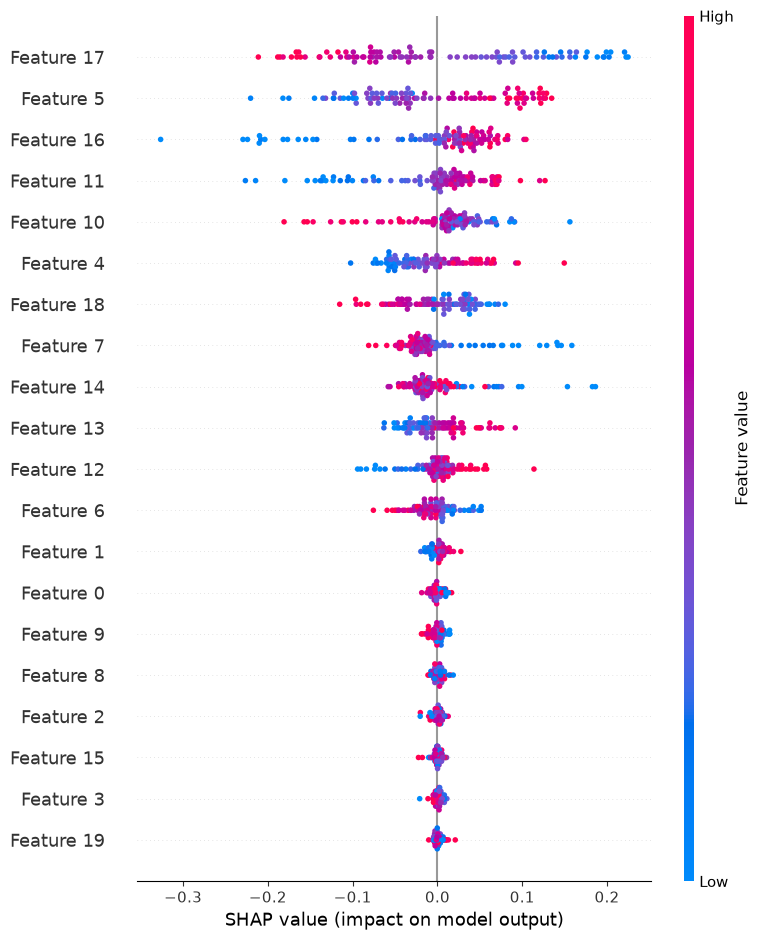

SHAP plot generated!


In [6]:
try:
    import shap
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr2, y_tr2)
    
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_te2[:100])
    
    # Handle both old API (list of arrays) and new API (single array)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(sv, X_te2[:100], show=False)
    plt.tight_layout()
    plt.savefig('/tmp/shap_summary.png', dpi=100)
    plt.show()
    print('SHAP plot generated!')
    
except ImportError:
    print('SHAP not installed. Install: pip install shap')
    print('Showing equivalent permutation importance...')
    
    from sklearn.inspection import permutation_importance
    rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr2, y_tr2)
    perm = permutation_importance(rf, X_te2, y_te2, n_repeats=10, random_state=42)
    
    imp_df = pd.DataFrame({'Feature': [f'F{i}' for i in range(X_te2.shape[1])],
                            'Importance': perm.importances_mean}).sort_values('Importance', ascending=True).tail(15)
    
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    ax.set_title('Permutation Importance (SHAP alternative)')
    ax.set_xlabel('Mean Accuracy Decrease when Feature is Shuffled')
    plt.tight_layout()
    plt.savefig('/tmp/perm_importance.png', dpi=100)
    plt.show()

## 5. Complete ML Checklist

```
PHASE 1: DATA
  □ Load data and check shape, dtypes
  □ Check missing values (count + %)
  □ Check duplicates
  □ Check class balance (classification)
  □ Check for data leakage

PHASE 2: EDA
  □ Univariate analysis (histograms, box plots)
  □ Target variable analysis
  □ Bivariate: each feature vs target
  □ Correlation heatmap
  □ Outlier detection

PHASE 3: PREPROCESSING
  □ Train/test split FIRST
  □ Handle missing values (fit on train only)
  □ Encode categoricals (OHE or Ordinal)
  □ Scale numerics (StandardScaler)
  □ Handle imbalance (class_weight or SMOTE)

PHASE 4: MODELING
  □ Start simple (LogReg baseline)
  □ Cross-validate multiple models
  □ Tune best model (RandomizedSearchCV)
  □ Evaluate on holdout test set ONCE

PHASE 5: DEPLOYMENT
  □ Save model (joblib/pickle)
  □ Create prediction function
  □ Build API (FastAPI/Flask)
  □ Monitor in production
```

In [7]:
# Final: the complete end-to-end function template
def train_ml_pipeline(df, target_col, test_size=0.2):
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.ensemble import GradientBoostingClassifier
    import joblib
    
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y)
    
    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                           ('sc',  StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                           ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
    ])
    
    pipeline = Pipeline([
        ('prep',  preprocessor),
        ('model', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ])
    
    pipeline.fit(X_train, y_train)
    auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1])
    print(f'Pipeline AUC-ROC on test set: {auc:.4f}')
    return pipeline

print('Template function defined.')
print('Usage: model = train_ml_pipeline(your_df, target_col="target")')

Template function defined.
Usage: model = train_ml_pipeline(your_df, target_col="target")


## You Are Ready!

You have completed the full Data Science & Machine Learning curriculum:

| Module | Topic |
|---|---|
| 01 | Python Basics |
| 02 | NumPy |
| 03 | Pandas |
| 04 | Visualization |
| 05 | EDA |
| 06 | Feature Engineering |
| 07 | Linear Regression |
| 08 | Logistic Regression |
| 09 | Decision Trees & Random Forest |
| 10 | SVM & KNN |
| 11 | Gradient Boosting / XGBoost |
| 12 | Clustering |
| 13 | PCA & Dimensionality Reduction |
| 14 | Model Selection & CV |
| 15 | Neural Networks |
| 16 | Time Series |
| 17 | NLP |
| 18 | End-to-End Project |
| 19 | Advanced Topics |

**Keep practicing on Kaggle.com — the best way to improve!**